In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import scipy.integrate as integrate
from scipy.interpolate import UnivariateSpline
import six
from tqdm.auto import tqdm

import taurex.log
taurex.log.disableLogging()
from taurex.cache import OpacityCache, CIACache
from taurex.planet import Planet
from taurex.stellar import PhoenixStar
from taurex.pressure import SimplePressureProfile
from taurex.temperature import Isothermal
from taurex.chemistry import TaurexChemistry
from taurex.data.profiles.chemistry.gas.constantgas import ConstantGas
from taurex.model import TransmissionModel
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from PyAstronomy import pyasl

In [2]:
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("/home/patcharawee/TauREx3_public/examples/parfiles/input/xsec/xsec_sampled_R15000_0.3-15")
CIACache().set_cia_path("/home/patcharawee/TauREx3_public/examples/parfiles/input/cia/HITRAN/data")

In [3]:
class Filters:
    def __init__(self, wavelengths, transit_depths):
        self.wavelengths = wavelengths # Angstroms
        self.transit_depths = transit_depths
        self.trans_funcs = pyasl.TransmissionCurves()
        self._add_sloan_filter()
        
    def _add_sloan_filter(self):
        base_path = '/home/patcharawee/Sloan'
        for band in ['u', 'g', 'r', 'i', 'z']:
            data = np.loadtxt(f'{base_path}/{band}.dat')
            self.trans_funcs.addPassband(f"Sloan {band}'", data[:,0], data[:,3], snc=True)
    
    def get_filter_curve(self, filter_name):
        filter_curve = self.trans_funcs.getTransCurve(filter_name)
        weight_curve = filter_curve(self.wavelengths)
        return weight_curve / np.sum(weight_curve) if np.sum(weight_curve) != 0 else weight_curve

    def get_binned_transit_depth(self, filter_name):
        weight_curve = self.get_filter_curve(filter_name)
        return np.average(self.transit_depths, weights=weight_curve)

    def get_binned_wavelength(self, filter_name):
        weight_curve = self.get_filter_curve(filter_name)
        return np.average(self.wavelengths, weights=weight_curve)

def calculate_semi_major_axis(period_days):
    G, M_sun, AU = 6.67430e-11, 1.989e30, 1.496e11
    P = period_days * 86400
    a_meters = ((G * M_sun * P**2) / (4 * np.pi**2))**(1/3)
    return a_meters / AU

In [4]:
filter_list = ["Bessel u", "Bessel b", "Bessel v", "Bessel r", "Bessel i", 
               "Sloan u'", "Sloan g'", "Sloan r'", "Sloan i'", "Sloan z'"]
Rp_list = [0.8, 1.0, 1.2, 1.4, 1.6, 1.8]

wl_arr, td_arr, td_zero_out = [], [], []

print("Starting Simulation...")
for rp in tqdm(Rp_list):
    # Star Setup
    star = PhoenixStar(temperature=5500, radius=1, distance=1, magnitudeK=10, mass=1, metallicity=1,
                       phoenix_path="/home/patcharawee/Phoenix/phoenix.astro.physik.uni-goettingen.de/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-1.0",
                       retro_version_file="/home/patcharawee/Phoenix/phoenix.astro.physik.uni-goettingen.de/v2.0/HiResFITS/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits")
    
    # Planet & Model Setup
    planet = Planet(planet_mass=1, planet_radius=rp, planet_distance=calculate_semi_major_axis(1), impact_param=0.5)
    temperature_profile = Isothermal(T=1500)
    pressure_profile = SimplePressureProfile(nlayers=100, atm_min_pressure=0.0001, atm_max_pressure=1000000.0)
    chemistry = TaurexChemistry(fill_gases=['H2', 'He'], ratio=0.1)
    chemistry.addGas(ConstantGas('TiO', mix_ratio=1e-6))
    chemistry.addGas(ConstantGas('VO', mix_ratio=1e-6))
    
    tm = TransmissionModel(planet=planet, star=star, pressure_profile=pressure_profile, 
                           temperature_profile=temperature_profile, chemistry=chemistry)
    tm.add_contribution(AbsorptionContribution())
    tm.add_contribution(CIAContribution(cia_pairs=['H2-H2', 'H2-He']))
    tm.add_contribution(RayleighContribution())
    tm.build()
    
    # Run Model
    native_grid, rprs, _, _ = tm.model()
    wvl = np.flip(10000/native_grid) * 1e3 # A
    td = np.flip(rprs)
    
    wl_arr.append(wvl)
    td_arr.append(td)
    
    td_zero_out.append(td - np.mean(td))

Starting Simulation...


  0%|          | 0/6 [00:00<?, ?it/s]

In [5]:
# StandardScaler
td_norm = []
for td in td_arr:
    normalized_td = (td - np.mean(td)) / np.std(td)
    td_norm.append(normalized_td)

# Photometric Binning (10 Filters)
bt_raw = []
bw_raw = []

for i in range(len(Rp_list)):
    f_class = Filters(wl_arr[i], td_arr[i])
    
    bt_list = [f_class.get_binned_transit_depth(band) for band in filter_list]
    bw_list = [f_class.get_binned_wavelength(band) for band in filter_list]
    
    bt_raw.append(np.array(bt_list))
    bw_raw.append(np.array(bw_list) * 1e-4)  # Convert to microns

# Binning
bt_zero_out = []
bt_norm = []

for bt in bt_raw:
    zeroed = bt - np.mean(bt)
    bt_zero_out.append(zeroed)
    
    normed = (bt - np.mean(bt)) / np.std(bt)
    bt_norm.append(normed)

/tmp/ipykernel_3243294/3193199704.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: combined_spectral_analysis.png


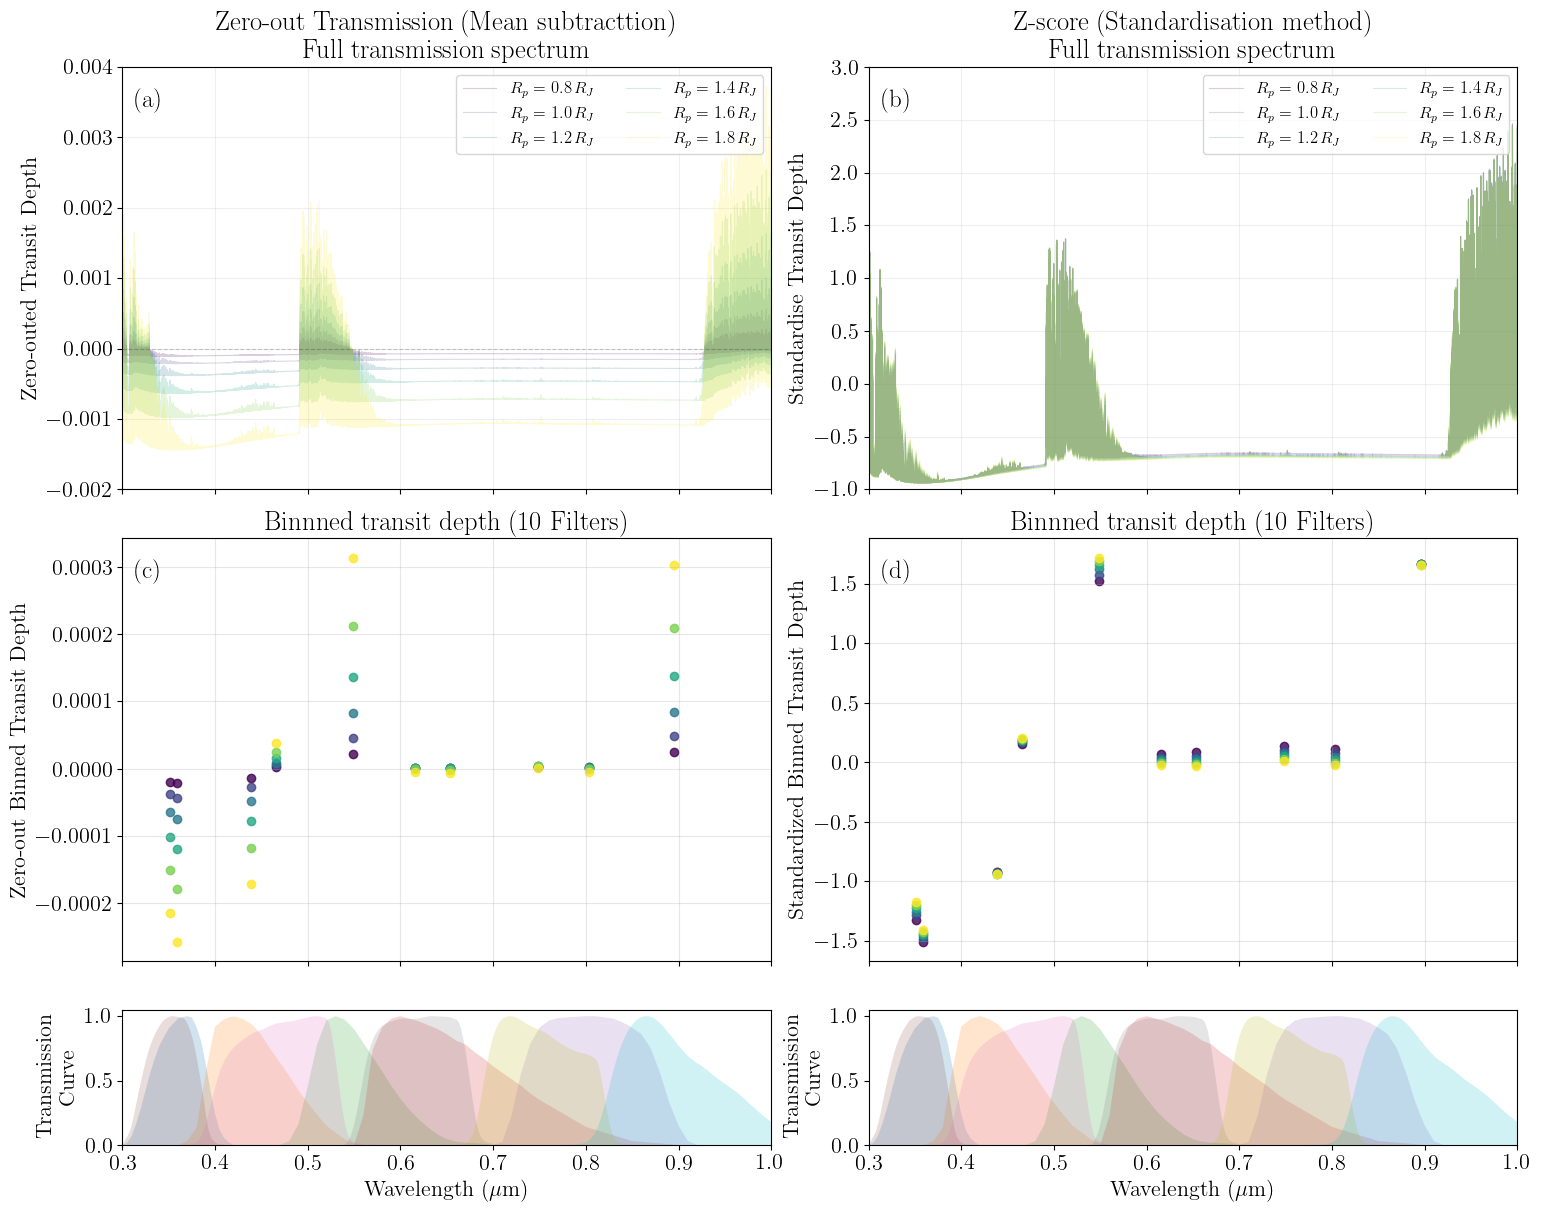

In [6]:
mpl.rcParams.update({
    'font.family': 'serif', 
    'font.size': 16, 
    'text.usetex': True
})

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[2.5, 2.5, 0.8], hspace=0.15, wspace=0.15)

ax_hz = fig.add_subplot(gs[0, 0])
ax_hn = fig.add_subplot(gs[0, 1])
ax_bz = fig.add_subplot(gs[1, 0], sharex=ax_hz)
ax_bn = fig.add_subplot(gs[1, 1], sharex=ax_hn)
ax_fz = fig.add_subplot(gs[2, 0], sharex=ax_hz)
ax_fn = fig.add_subplot(gs[2, 1], sharex=ax_hn)

colors = plt.cm.viridis(np.linspace(0, 1, len(Rp_list)))
wl_um = [w * 1e-4 for w in wl_arr]

# -- Row 1: High-Res Spectra --
for i, rp in enumerate(Rp_list):
    # Left: Zero-out
    ax_hz.plot(wl_um[i], td_zero_out[i], color=colors[i], 
               label=rf"$R_p = {rp}\,R_J$", alpha=0.2, lw=0.8)
    # Right: Standardized
    ax_hn.plot(wl_um[i], td_norm[i], color=colors[i], 
               label=rf"$R_p = {rp}\,R_J$", alpha=0.2, lw=0.8)

ax_hz.axhline(0, color='k', lw=0.8, ls='--', alpha=0.2)
ax_hz.set_ylabel("Zero-outed Transit Depth")
ax_hz.set_ylim(-0.002, 0.004)
ax_hz.set_title("Zero-out Transmission (Mean subtracttion) \n Full transmission spectrum")
ax_hz.legend(loc='upper right', fontsize=12, ncol=2)
ax_hz.grid(True, alpha=0.2)

ax_hn.set_ylabel("Standardise Transit Depth")
ax_hn.set_ylim(-1, 3)
ax_hn.set_title("Z-score (Standardisation method) \n Full transmission spectrum")
ax_hn.legend(loc='upper right', fontsize=12, ncol=2)
ax_hn.grid(True, alpha=0.2)

# -- Row 2: Binned Spectra --
for i, rp in enumerate(Rp_list):
    # Left: Binned Zero-out
    ax_bz.scatter(bw_raw[i], bt_zero_out[i], color=colors[i], 
                  label=rf"$R_p = {rp}\,R_J$", alpha=0.8)
    # Right: Binned Standardized
    ax_bn.scatter(bw_raw[i], bt_norm[i], color=colors[i], 
                  label=rf"$R_p = {rp}\,R_J$", alpha=0.8)

ax_bz.set_ylabel("Zero-out Binned Transit Depth")
ax_bz.set_title("Binnned transit depth (10 Filters)")
ax_bz.grid(True, alpha=0.3)

ax_bn.set_ylabel("Standardized Binned Transit Depth")
ax_bn.set_title("Binnned transit depth (10 Filters)")
ax_bn.grid(True, alpha=0.3)

# -- Row 3: Filter Transmission Curves --
filters_obj = Filters(wl_arr[-1], td_arr[-1])

for band in filter_list:
    f_curve = filters_obj.get_filter_curve(band)
    norm_curve = f_curve / np.max(f_curve)
    
    ax_fz.fill_between(wl_um[-1], norm_curve, alpha=0.2, label=band)
    ax_fn.fill_between(wl_um[-1], norm_curve, alpha=0.2, label=band)

for ax in [ax_fz, ax_fn]:
    ax.set_xlabel(r"Wavelength ($\mu$m)")
    ax.set_ylabel("Transmission\nCurve")
    ax.set_xlim(0.3, 1.0)
    ax.set_ylim(0, 1.05)

for ax in [ax_hz, ax_hn, ax_bz, ax_bn]:
    plt.setp(ax.get_xticklabels(), visible=False)

axes = [ax_hz, ax_hn, ax_bz, ax_bn, ax_fz, ax_fn]
labels = ['(a)', '(b)', '(c)', '(d)']

for ax, label in zip(axes, labels):
    ax.annotate(
        label, 
        xy=(0.02, 0.95),         
        xycoords='axes fraction',
        fontsize=18, 
        va='top',                
        ha='left'                
    )

plt.tight_layout()
plt.savefig('combined_spectral_analysis.png', dpi=300)
print("Saved: combined_spectral_analysis.png")
plt.show()

In [7]:
# Panel (a)
delta_zero_out_a = bt_zero_out[-1] - bt_zero_out[0]
delta_norm_a = bt_norm[-1] - bt_norm[0]

amp_zero_out_a = np.max(bt_zero_out[0]) - np.min(bt_zero_out[0])
pct_delta_zero_out_a = (delta_zero_out_a / amp_zero_out_a) * 100

amp_norm_a = np.max(bt_norm[0]) - np.min(bt_norm[0])
pct_delta_norm_a = (delta_norm_a / amp_norm_a) * 100

# Panel (b)
delta_zero_out_b = bt_zero_out[1] - bt_zero_out[0]
delta_norm_b = bt_norm[1] - bt_norm[0]

amp_zero_out_b = np.max(bt_zero_out[0]) - np.min(bt_zero_out[0])
pct_delta_zero_out_b = (delta_zero_out_b / amp_zero_out_b) * 100

amp_norm_b = np.max(bt_norm[0]) - np.min(bt_norm[0])
pct_delta_norm_b = (delta_norm_b / amp_norm_b) * 100

bw_um_binned = bw_raw[0]

# calculate RMSD & MAD
def get_stats(data):
    rmsd = np.sqrt(np.mean(np.square(data)))
    mad = np.mean(np.abs(data))
    return rmsd, mad

rmsd_z_a, mad_z_a = get_stats(pct_delta_zero_out_a)
rmsd_n_a, mad_n_a = get_stats(pct_delta_norm_a)

rmsd_z_b, mad_z_b = get_stats(pct_delta_zero_out_b)
rmsd_n_b, mad_n_b = get_stats(pct_delta_norm_b)

/tmp/ipykernel_3243294/2362523331.py:51: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  ax[1].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)


Saved: combined_pct_delta_comparison.png


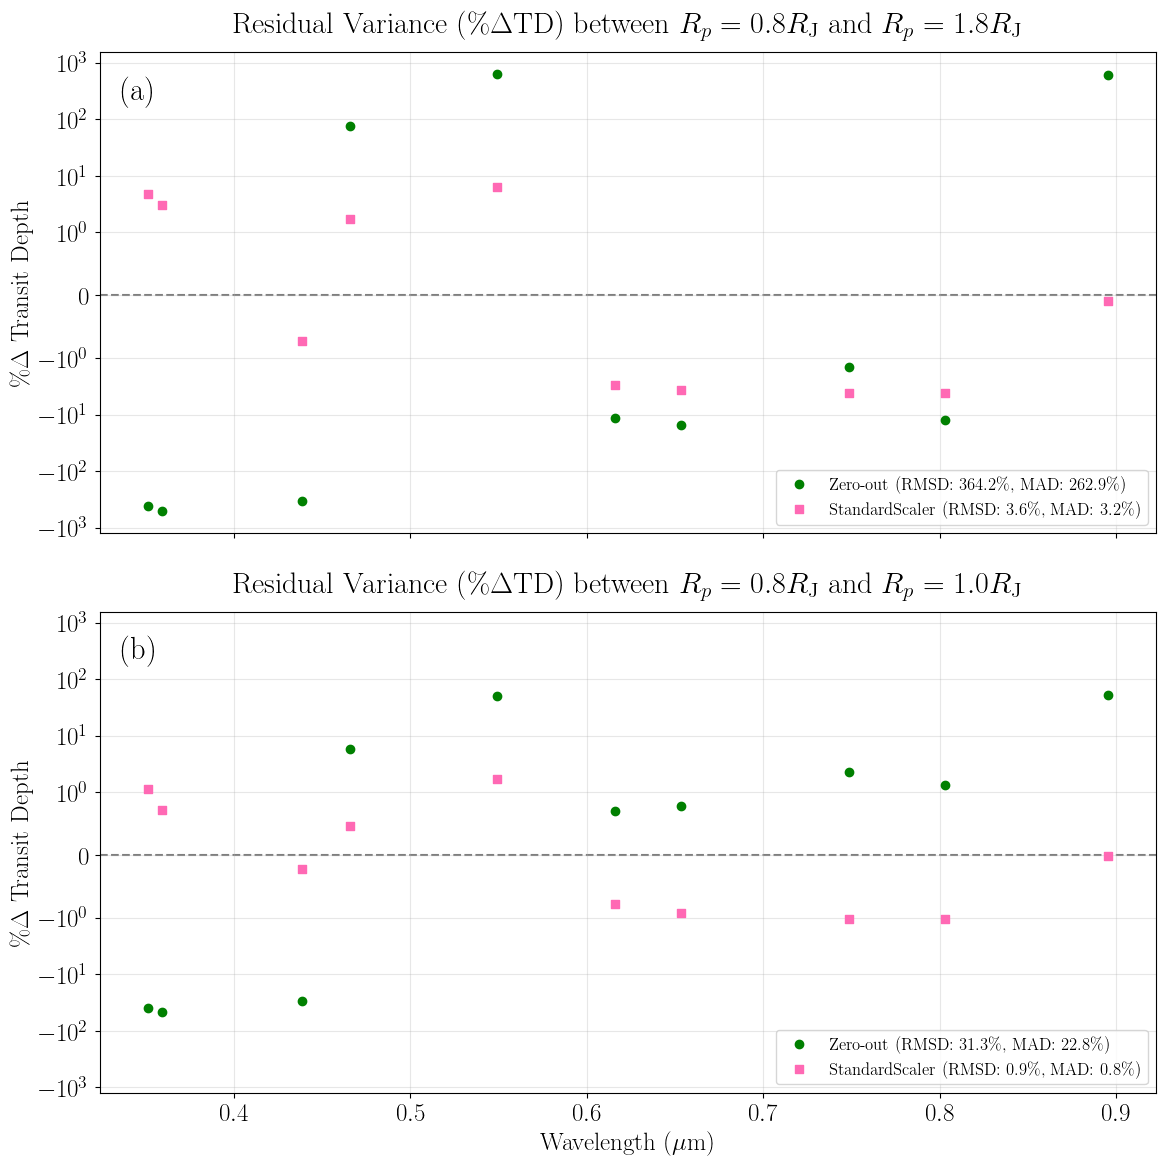

In [8]:
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'text.usetex': True
})

fig, ax = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

title_str_a = (
    rf"Residual Variance (\%$\Delta$TD) between "
    rf"$R_p = {Rp_list[0]}R_\mathrm{{J}}$ and $R_p = {Rp_list[-1]}R_\mathrm{{J}}$"
)
title_str_b = (
    rf"Residual Variance (\%$\Delta$TD) between "
    rf"$R_p = {Rp_list[0]}R_\mathrm{{J}}$ and $R_p = {Rp_list[1]}R_\mathrm{{J}}$"
)

# Panel (a)
label_z_a = rf"Zero-out (RMSD: {rmsd_z_a:.1f}\%, MAD: {mad_z_a:.1f}\%)"
label_n_a = rf"StandardScaler (RMSD: {rmsd_n_a:.1f}\%, MAD: {mad_n_a:.1f}\%)"

ax[0].scatter(
    bw_um_binned, pct_delta_zero_out_a,
    marker='o', color='green', zorder=4, label=label_z_a
)
ax[0].scatter(
    bw_um_binned, pct_delta_norm_a,
    marker='s', color='hotpink', zorder=3, label=label_n_a
)

ax[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)
ax[0].set_yscale('symlog', linthresh=1.0)
ax[0].set_ylabel(r"$\%\Delta$ Transit Depth")
ax[0].set_title(title_str_a, pad=15)
ax[0].legend(loc='lower right', fontsize=12)
ax[0].grid(True, alpha=0.3)

# Panel (b)
label_z_b = rf"Zero-out (RMSD: {rmsd_z_b:.1f}\%, MAD: {mad_z_b:.1f}\%)"
label_n_b = rf"StandardScaler (RMSD: {rmsd_n_b:.1f}\%, MAD: {mad_n_b:.1f}\%)"

ax[1].scatter(
    bw_um_binned, pct_delta_zero_out_b,
    marker='o', color='green', zorder=4, label=label_z_b
)
ax[1].scatter(
    bw_um_binned, pct_delta_norm_b,
    marker='s', color='hotpink', zorder=3, label=label_n_b
)

ax[1].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)
ax[1].set_yscale('symlog', linthresh=1.0)
ax[1].set_ylabel(r"$\%\Delta$ Transit Depth")
ax[1].set_xlabel(r"Wavelength ($\mu$m)")
ax[1].set_title(title_str_b, pad=15)
ax[1].legend(loc='lower right', fontsize=12)
ax[1].grid(True, alpha=0.3)

axes = [ax[0], ax[1]]
labels = ['(a)', '(b)']

for this_ax, label in zip(axes, labels):
    this_ax.annotate(
        label,
        xy=(0.02, 0.95),              
        xycoords='axes fraction',     
        fontsize=22,
        va='top',                     
        ha='left'                     
    )

plt.tight_layout()
plt.savefig('combined_pct_delta_comparison.png', dpi=300)
print("Saved: combined_pct_delta_comparison.png")
plt.show()